In [1]:
# PATH_ROOT

from pathlib import Path
import sys
project_root = Path.cwd().parent  
sys.path.insert(0, str(project_root))


In [2]:
#  --IMPORTS--

import pandas as pd
import numpy as np
import datetime as dt
import scipy.stats as norm
import matplotlib.pyplot as plt

In [3]:
#  --IMPORTING FUNCTIONS--

from dataa.h_data import (get_price)
from dataa.ticker_list import (tickers)
from dataa.wt_distribution import (wt_distribution)

from src.returns import (cal_returns)
from src.hist_return import (hist_return)
from src.var_parametric import (cal_var_s)
from src.cvar_para import (cal_cvar_p)
from src.x_day import (xday_return_calc)

In [4]:
#  --INPUTS--

portfolio = float(input("Enter portfolio value in Rs : "))
confidence = float(input("Enter the confidence for both VaR and CVaR calculation: "))
days = int(input("Enter the time window for calculation: ")) 

In [5]:
#  --WEIGHT DISTRUBUTION OF PORTFOLIO--


weights = wt_distribution(tickers)

print("\n\tWEIGHT DISTRIBUTION PER STOCK\n")
for w, t in zip(weights, tickers):
    print(f"{t}:\t \t {w}")


 ---------- 	For weight of portfolio ----------

 a) Equally distributed 
 b) Insert weight of each stock 


	WEIGHT DISTRIBUTION PER STOCK

RELIANCE.NS:	 	 0.1
ITC.NS:	 	 0.1
SBIN.NS:	 	 0.1
HDFCBANK.NS:	 	 0.1
BPCL.NS:	 	 0.1
IOC.NS:	 	 0.1
ONGC.NS:	 	 0.1
SAIL.NS:	 	 0.1
TATACHEM.NS:	 	 0.1
HINDALCO.NS:	 	 0.1


In [6]:
#  ----REGIMES----
regimes = {
           " Post_Liberalization_Boom " : ("1996-01-01", "1997-12-31"),
           " Asian_Crisis_Impact      " : ("1998-01-01", "1998-12-31"),
           " DotCom_Pre_Bubble        " : ("1999-01-01", "2000-02-29"),
           " DotCom_Crash_Bear_Market " : ("2000-03-01", "2001-09-30"),
           " Post_DotCom_Recovery     " : ("2001-10-01", "2003-12-31"),
           " Pre_GlobalFinCrisis      " : ("2004-01-01", "2007-12-31"),
           " Global_Financial_Crisis  " : ("2008-01-01", "2009-12-31"),
           " Post_GlobalFinCrisis     " : ("2010-01-01", "2019-12-31"),
           " COVID_Crash              " : ("2020-02-01", "2020-04-30"),
           " COVID_Recovery           " : ("2020-05-01", "2021-12-31"),
           " Inflation_Rate_Hike      " : ("2022-01-01", "2023-12-31"),
           " AI_Boom                  " : ("2024-01-01", "2025-12-31")
          }


In [12]:
# CALCULATING RETURNS, VAR AND CVAR FOR EACH REGIME

results = []
oth_data = []
for reg, date in regimes.items():

    start = dt.datetime.strptime(date[0], "%Y-%m-%d")
    end = dt.datetime.strptime(date[1], "%Y-%m-%d")

    # DOWNLOADING THE ADJACENT CLOSE PRICE FOR EACH STOCK OF PORTFOLIO
    price = get_price(tickers, start, end)

    # LOG RETURNS OF PORTFOLIO
    log_returns = cal_returns(price)

    # CALCULATING HISTORICAL RETURN I.E. RETURN OF ENTIRE PORTFOLIO HISTORICALLY
    historical_returns = hist_return(log_returns, weights)

    # CALCULATING PORTFOLIO RETURNS FOR X-DAY
    xday_rtrn = xday_return_calc(historical_returns, days)
    xday_portf = xday_rtrn * portfolio

    # CALCULATING VALUE_AT_RISK THROUGH PARAMETRIC METHOD 
    P_VAR = cal_var_s(returns = log_returns, cl= confidence, w= weights, d= days, value= portfolio)
    VAR = round(float(np.squeeze(P_VAR)), 2)
    VAR_p = VAR/portfolio * 100
    VAR_p = round(float(VAR_p), 2)

    # CALCULATING CONDITIONAL VALUE_AT_RISK THROUGH PARAMETRIC METHOD
    P_CVAR = cal_cvar_p(cl= confidence, value= portfolio, retu_rn = log_returns, wt= weights, d= days)
    CVAR = round(float(np.squeeze(P_CVAR)), 2)
    CVAR_p = CVAR/portfolio * 100
    CVAR_p = round(float(CVAR_p), 2)

   
    results.append([reg, start, end, VAR, CVAR, VAR_p, CVAR_p])
    oth_data.append([reg, VAR, CVAR, xday_portf])



[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%********

In [13]:
#  --DATAFRAME OF ALL CALCULATED VALUES--

print("\n \n")
Regime_Risk_df = pd.DataFrame(results, columns=["Regimes",
                                                "Start_date",
                                                "End_date",
                                                "Value_at_Risk",
                                                "Conditional_VaR",
                                                "VaR %",
                                                "CVaR %"
                                                ])

print(Regime_Risk_df)

Visual_df = pd.DataFrame(oth_data, columns=["Regimes",
                                             "Value-at-Risk",
                                             "CValue-at-Risk",
                                             "XDAY_RETURNS"])



 

                       Regimes Start_date   End_date  Value_at_Risk  \
0    Post_Liberalization_Boom  1996-01-01 1997-12-31      248123.51   
1    Asian_Crisis_Impact       1998-01-01 1998-12-31      402561.30   
2    DotCom_Pre_Bubble         1999-01-01 2000-02-29      502190.71   
3    DotCom_Crash_Bear_Market  2000-03-01 2001-09-30      191351.58   
4    Post_DotCom_Recovery      2001-10-01 2003-12-31      136650.75   
5    Pre_GlobalFinCrisis       2004-01-01 2007-12-31      332785.95   
6    Global_Financial_Crisis   2008-01-01 2009-12-31      280790.86   
7    Post_GlobalFinCrisis      2010-01-01 2019-12-31      134740.50   
8    COVID_Crash               2020-02-01 2020-04-30      426597.22   
9    COVID_Recovery            2020-05-01 2021-12-31      158832.39   
10   Inflation_Rate_Hike       2022-01-01 2023-12-31      120163.98   
11   AI_Boom                   2024-01-01 2025-12-31      136800.91   

    Conditional_VaR  VaR %  CVaR %  
0         311156.89  11.50   14.42 

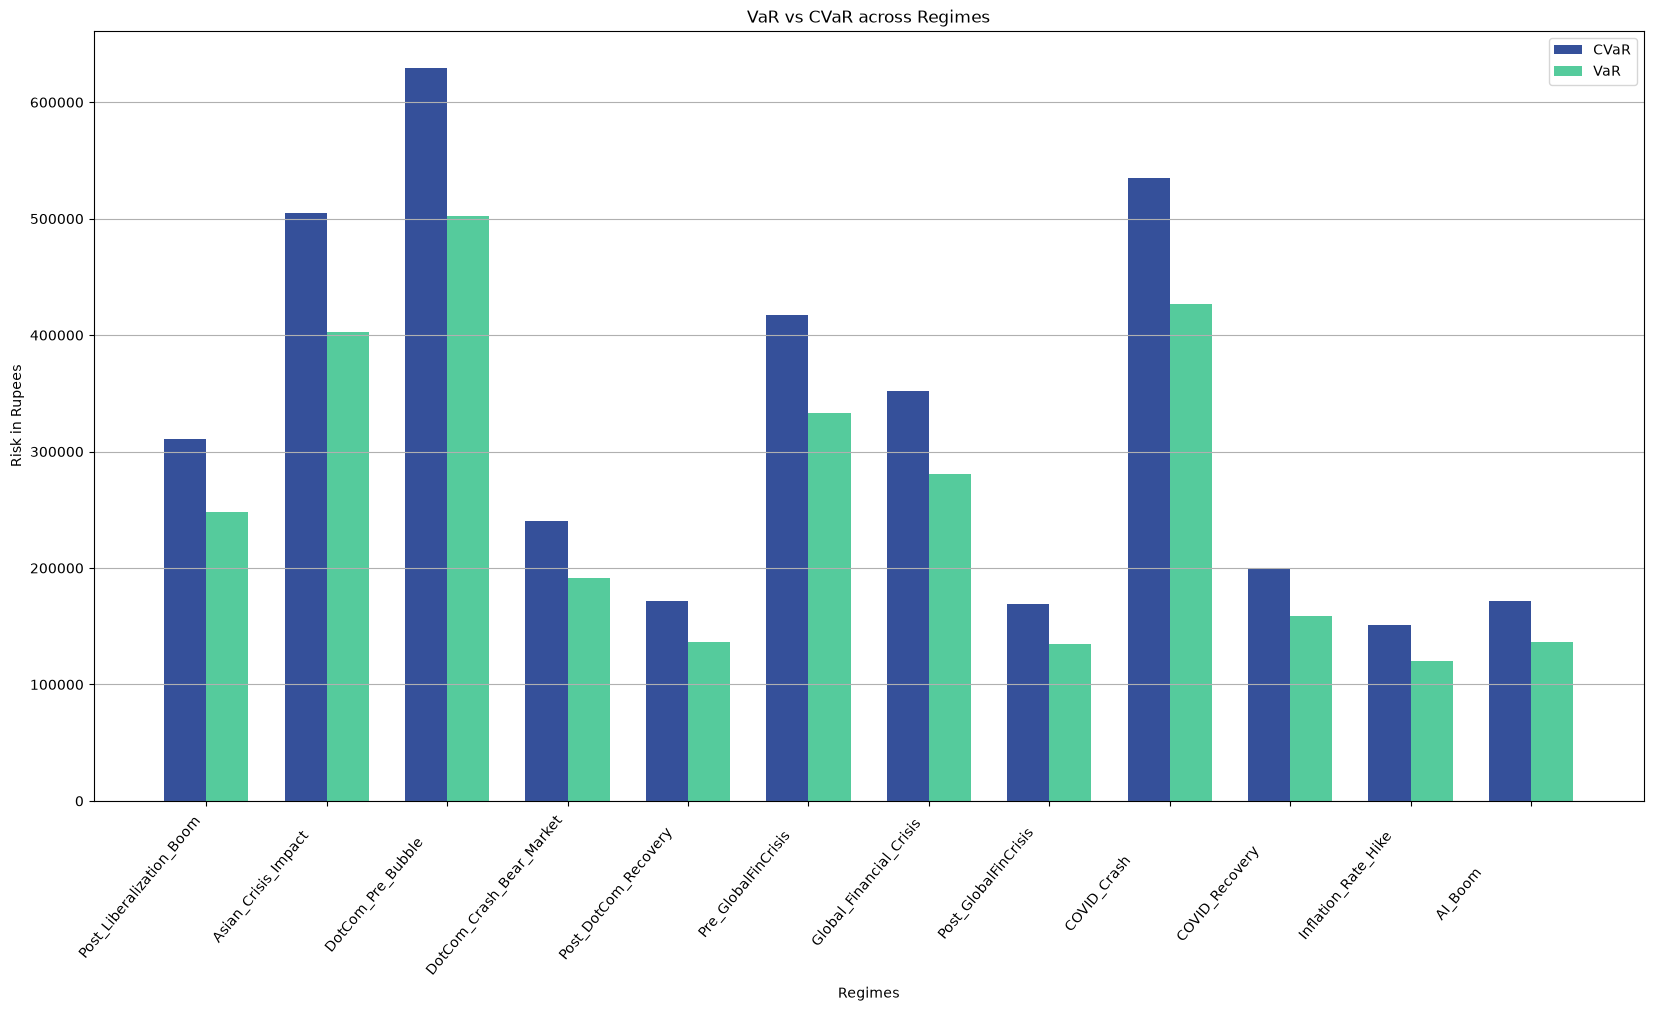

In [9]:
#  --VISUALISATION--

#  A) BAR CHART COMPARISON OF VaR vs CVaR

x = np.arange(len(Regime_Risk_df["Regimes"]))
y = Regime_Risk_df["Value_at_Risk"]
z = Regime_Risk_df["Conditional_VaR"]
plt.figure(figsize=(20, 10))
width = 0.35
plt.bar(x - width/2 , z, width, label = "CVaR", color = "#35509a")
plt.bar(x + width/2, y, width, label = "VaR", color = "#55cb9c")
plt.xlabel("Regimes")
plt.xticks(x,Regime_Risk_df["Regimes"], rotation = 50, ha = "right")
plt.ylabel("Risk in Rupees")
plt.title("VaR vs CVaR across Regimes")
plt.grid(axis = "y")
plt.legend()
plt.savefig("Bar_Comparison.png", dpi = 300, bbox_inches = "tight")


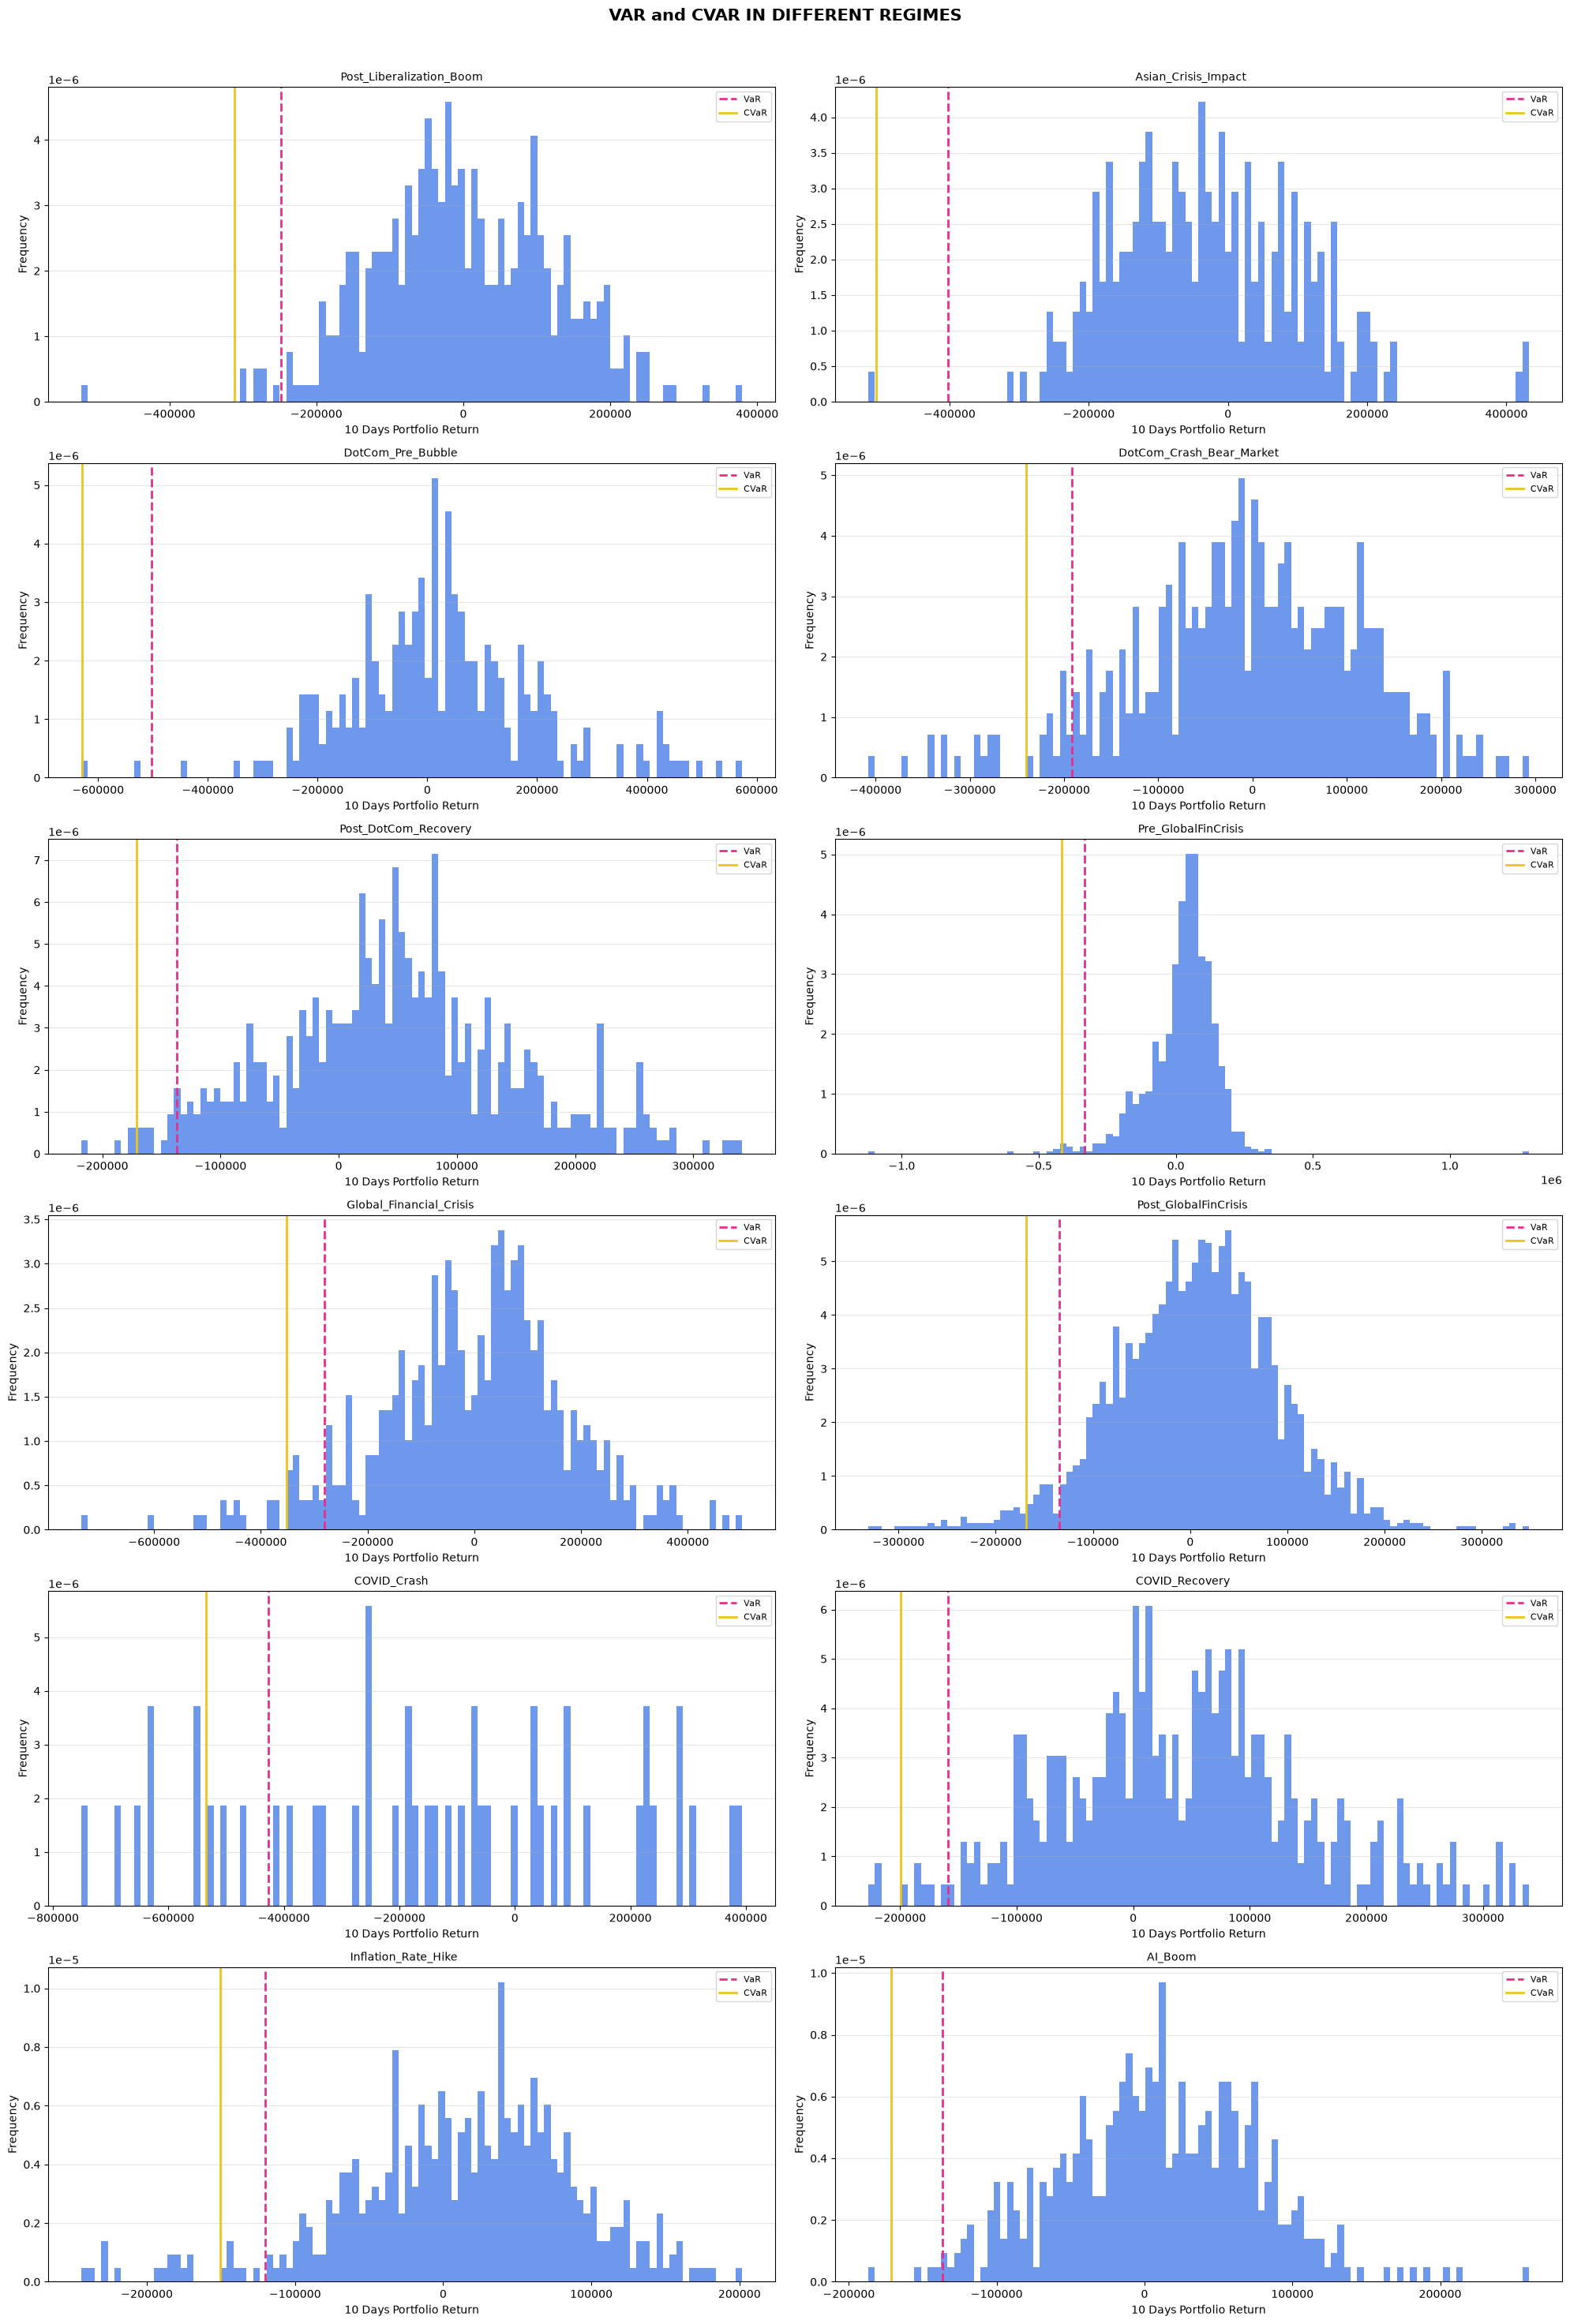

In [11]:
# ---- VISUALISATION ----
# B) HISTOGRAM FOR EACH REGIME WITH VaR AND CVaR

fig, axes = plt.subplots(nrows=6, ncols=2, figsize=(20, 30))

axes = axes.flatten()

for ax, (_, row) in zip(axes, Visual_df.iterrows()):

    # Historical return distribution for this regime
    returns = np.asarray(row["XDAY_RETURNS"]).flatten()

    # Risk measures
    var = row["Value-at-Risk"]
    cvar = row["CValue-at-Risk"]

    # Histogram
    ax.hist(returns, bins=100, color="#316ce4", alpha=0.7, density= "True")

    # VaR
    ax.axvline(-var, color="#e92d8b", linestyle="--", linewidth=2, label="VaR")

    # CVaR
    ax.axvline(-cvar, color="#ebc51c", linestyle="-", linewidth=2, label="CVaR")

    ax.set_title(row["Regimes"], fontsize=10)
    ax.set_xlabel(f"{days} Days Portfolio Return")
    ax.set_ylabel("Frequency")
    ax.grid(axis="y", alpha=0.3)

    # One legend per subplot
    ax.legend(fontsize=8)

plt.suptitle(
    "VAR and CVAR IN DIFFERENT REGIMES", fontsize=15, fontweight="bold")

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.savefig("VaR_CVaR_histogram.png", dpi=300, bbox_inches="tight")

plt.show()